# Gradients, Hessians, and Second-Order Sufficient Conditions
### MECH 559 - Systems Optimization - L05
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

This notebook builds the vector/matrix machinery behind the lecture's second-order theory: gradients and Hessians, the quadratic-function identities, the second-order sufficient condition (SOSC), and the three practical tests for positive definiteness. It ends by reproducing the lecture's three worked examples and the classification table.

## Learning objectives

By the end, students should be able to:

1. Compute the gradient and Hessian of a quadratic function and verify $\nabla f = A\mathbf{x}+\mathbf{b}$, $H=A$.
2. Test a symmetric matrix for positive (semi-)definiteness three ways: the quadratic-form test, eigenvalues, and leading principal minors.
3. Apply the SOSC to classify a stationary point as a minimizer, maximizer, or saddle.
4. Reproduce the lecture's three worked quadratic examples and connect each Hessian type to the shape of its function.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49"}

print(f"NumPy {np.__version__}; optional widgets available: {WIDGETS_AVAILABLE}")

NumPy 2.5.0; optional widgets available: True


---
## 1. Gradient and Hessian of a quadratic function

For

$$
f(\mathbf{x}) = \tfrac12\mathbf{x}^{\mathrm T}A\mathbf{x} + \mathbf{x}^{\mathrm T}\mathbf{b} + c, \qquad A \in \mathbb{R}^{n\times n} \text{ symmetric},
$$

the slide states three identities:

$$
\nabla f = A\mathbf{x}+\mathbf{b}, \qquad H = A, \qquad \nabla f_2-\nabla f_1 = H(\mathbf{x}_2-\mathbf{x}_1).
$$

We verify all three numerically (against a central-difference gradient/Hessian) for a random symmetric $2\times2$ $A$.

In [3]:
def numerical_gradient(func, x, h=1e-5):
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    for i in range(len(x)):
        step = np.zeros_like(x); step[i] = h
        g[i] = (func(x + step) - func(x - step)) / (2 * h)
    return g

def numerical_hessian(func, x, h=1e-4):
    n = len(x)
    H_num = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            step_i = np.zeros(n); step_i[i] = h
            step_j = np.zeros(n); step_j[j] = h
            H_num[i, j] = (func(x + step_i + step_j) - func(x + step_i - step_j)
                           - func(x - step_i + step_j) + func(x - step_i - step_j)) / (4 * h**2)
    return H_num

rng = np.random.default_rng(0)
M = rng.normal(size=(2, 2))
A = (M + M.T) / 2          # symmetric by construction
b = rng.normal(size=2)
c = rng.normal()

def quad(x, A=A, b=b, c=c):
    return 0.5 * x @ A @ x + b @ x + c

x0 = rng.normal(size=2)
print("A =\n", A)
print("analytic  grad =", A @ x0 + b)
print("numerical grad =", numerical_gradient(quad, x0))
print("analytic  H =\n", A)
print("numerical H =\n", numerical_hessian(quad, x0))

x1_pt, x2_pt = rng.normal(size=2), rng.normal(size=2)
lhs = (A @ x2_pt + b) - (A @ x1_pt + b)
rhs = A @ (x2_pt - x1_pt)
print()
print("grad(x2)-grad(x1) == H (x2-x1):", np.allclose(lhs, rhs))

A =
 [[0.12573022 0.25415889]
 [0.25415889 0.10490012]]
analytic  grad = [-0.59545324  0.5284822 ]
numerical grad = [-0.59545324  0.5284822 ]
analytic  H =
 [[0.12573022 0.25415889]
 [0.25415889 0.10490012]]
numerical H =
 [[0.12573021 0.25415889]
 [0.25415889 0.10490012]]

grad(x2)-grad(x1) == H (x2-x1): True


---
## 2. Three tests for positive definiteness

A square symmetric $A$ is positive definite iff any one of these holds (they are equivalent):

1. $y^{\mathrm T}Ay > 0$ for every $y \neq 0$ (quadratic-form test).
2. Every eigenvalue of $A$ is positive.
3. Every leading principal minor of $A$ is positive.

We implement all three and use them together (agreement is the point - any single one is enough in practice, but seeing them agree builds confidence they are really equivalent).

In [4]:
def leading_principal_minors(A):
    return [np.linalg.det(A[:k, :k]) for k in range(1, A.shape[0] + 1)]

def classify_definiteness(A, tol=1e-9):
    eigs = np.linalg.eigvalsh(A)
    if np.all(eigs > tol):
        return "positive definite", eigs
    if np.all(eigs >= -tol):
        return "positive semi-definite", eigs
    if np.all(eigs < -tol):
        return "negative definite", eigs
    if np.all(eigs <= tol):
        return "negative semi-definite", eigs
    return "indefinite", eigs

def quadratic_form_samples(A, n_samples=5, seed=0):
    rng_local = np.random.default_rng(seed)
    ys = rng_local.normal(size=(n_samples, A.shape[0]))
    return np.array([y @ A @ y for y in ys])

A_test = np.array([[4.0, 1.0], [1.0, 3.0]])
label, eigs = classify_definiteness(A_test)
print("A =\n", A_test)
print("classification:", label)
print("eigenvalues:", eigs)
print("leading principal minors:", leading_principal_minors(A_test))
print("y^T A y for 5 random y:", quadratic_form_samples(A_test))

A =
 [[4. 1.]
 [1. 3.]]
classification: positive definite
eigenvalues: [2.38196601 4.61803399]
leading principal minors: [np.float64(4.0), np.float64(11.000000000000002)]
y^T A y for 5 random y: [ 0.08236829  1.80793761  1.15262887 11.96253876  8.56589098]


---
## 3. The lecture's three worked examples

$$
f_1(x_1,x_2)=x_1^2-3x_1x_2+4x_2^2+x_1-x_2 \qquad
f_2(x_1,x_2)=4x_1^2-4x_1x_2+x_2^2-4x_1+2x_2 \qquad
f_3(x_1,x_2)=-x_1^2+x_2^2
$$

Each is quadratic, so its Hessian is constant everywhere: we can classify $f_i$ once and know the nature of *every* stationary point (per the Summary table). Writing each as $\tfrac12\mathbf{x}^{\mathrm T}A_i\mathbf{x}+\mathbf{x}^{\mathrm T}b_i$ gives $A_1=\begin{bmatrix}2&-3\\-3&8\end{bmatrix}$, $A_2=\begin{bmatrix}8&-4\\-4&2\end{bmatrix}$, $A_3=\begin{bmatrix}-2&0\\0&2\end{bmatrix}$.

f1 (claimed positive definite): classified as 'positive definite'  |  eigenvalues=[0.757 9.243]  |  minors=[2. 7.]
   unique stationary point: [-0.7143 -0.1429]
f2 (claimed positive semi-definite): classified as 'positive semi-definite'  |  eigenvalues=[ 0. 10.]  |  minors=[8. 0.]
   A is singular: a whole line of stationary points through [ 0.4 -0.2]
f3 (claimed indefinite): classified as 'indefinite'  |  eigenvalues=[-2.  2.]  |  minors=[-2. -4.]
   unique stationary point: [-0. -0.]


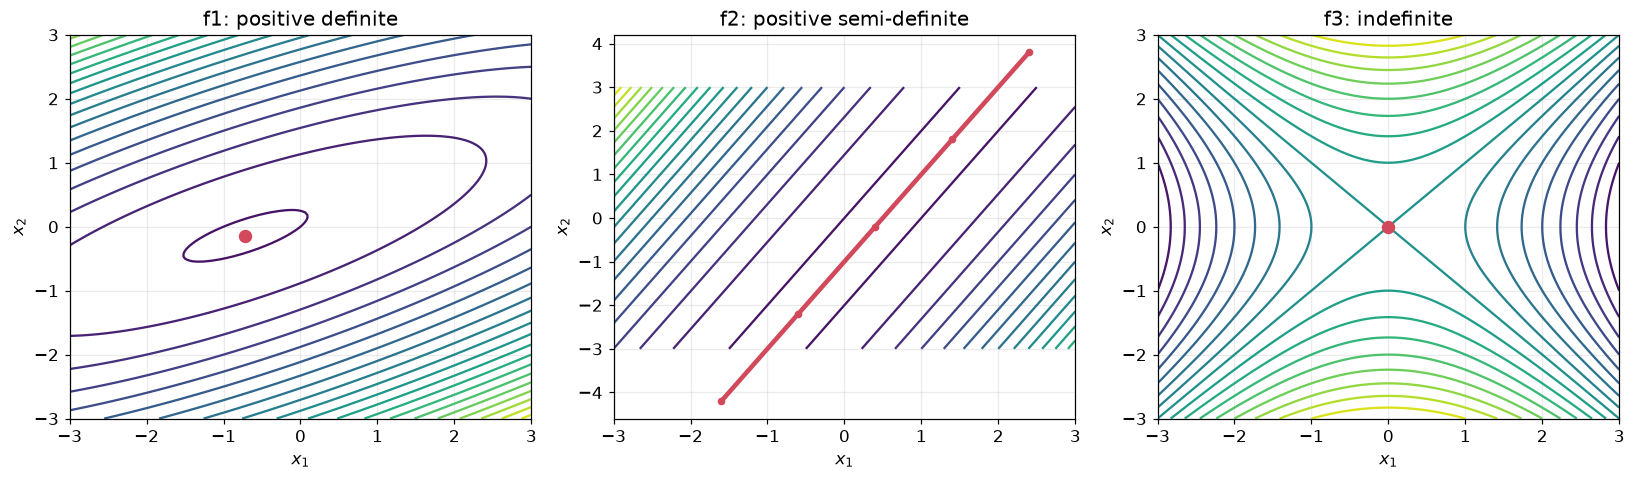

In [5]:
problems = {
    "f1 (claimed positive definite)": (np.array([[2., -3.], [-3., 8.]]), np.array([1., -1.])),
    "f2 (claimed positive semi-definite)": (np.array([[8., -4.], [-4., 2.]]), np.array([-4., 2.])),
    "f3 (claimed indefinite)": (np.array([[-2., 0.], [0., 2.]]), np.array([0., 0.])),
}

fig = plt.figure(figsize=(15, 4.5))
for i, (name, (A_i, b_i)) in enumerate(problems.items()):
    label, eigs = classify_definiteness(A_i)
    minors = leading_principal_minors(A_i)
    print(f"{name}: classified as '{label}'  |  eigenvalues={np.round(eigs,3)}  |  minors={np.round(minors,3)}")

    try:
        x_star = np.linalg.solve(A_i, -b_i)
        print(f"   unique stationary point: {np.round(x_star, 4)}")
        stationary_pts = np.array([x_star])
    except np.linalg.LinAlgError:
        x_particular, *_ = np.linalg.lstsq(A_i, -b_i, rcond=None)
        print(f"   A is singular: a whole line of stationary points through {np.round(x_particular, 4)}")
        direction = np.array([A_i[1, 1], -A_i[0, 1]])  # null-space direction of a symmetric 2x2
        stationary_pts = np.array([x_particular + t * direction for t in np.linspace(-1, 1, 5)])

    def f_i(x, A_i=A_i, b_i=b_i):
        return 0.5 * x @ A_i @ x + b_i @ x

    x1g, x2g = np.meshgrid(np.linspace(-3, 3, 150), np.linspace(-3, 3, 150))
    Z = 0.5 * (A_i[0, 0]*x1g**2 + 2*A_i[0, 1]*x1g*x2g + A_i[1, 1]*x2g**2) + b_i[0]*x1g + b_i[1]*x2g

    ax = fig.add_subplot(1, 3, i + 1)
    ax.contour(x1g, x2g, Z, levels=20, cmap="viridis")
    if len(stationary_pts) > 1:
        ax.plot(stationary_pts[:, 0], stationary_pts[:, 1], color=COLORS["optimum"], lw=3, marker="o", markersize=4)
    else:
        ax.scatter(stationary_pts[:, 0], stationary_pts[:, 1], color=COLORS["optimum"], s=60, zorder=3)
    ax.set_title(f"{name.split(' ')[0]}: {label}")
    ax.set(xlabel="$x_1$", ylabel="$x_2$")
plt.tight_layout()
plt.show()

---
## 4. Summary table

| If $H$ is (globally) | then stationary point(s) is (are) |
|---|---|
| positive definite | unique local (global) minimizer |
| positive semi-definite | local (global) minimizers with the same minimum |
| negative definite | unique local (global) maximizer |
| negative semi-definite | local (global) maximizers with the same maximum |
| indefinite | inflection (saddle) points |

This matches exactly what the three examples above show: $f_1$ has one minimizer, $f_2$ has a whole line of minimizers sharing the same minimum value, and $f_3$'s single stationary point is a saddle.

In [6]:
A2, b2 = problems["f2 (claimed positive semi-definite)"]
def f2_func(x):
    return 0.5 * x @ A2 @ x + b2 @ x
x_particular, *_ = np.linalg.lstsq(A2, -b2, rcond=None)
direction = np.array([A2[1, 1], -A2[0, 1]])
values = [f2_func(x_particular + t*direction) for t in np.linspace(-2, 2, 9)]
print("f2 along the line of minimizers:", np.round(values, 6), "-> constant, as the table predicts")

f2 along the line of minimizers: [-1. -1. -1. -1. -1. -1. -1. -1. -1.] -> constant, as the table predicts


---
## 5. Interactive: classify a $2\times2$ symmetric matrix

Move the sliders to change $A=\begin{bmatrix}a_{11}&a_{12}\\a_{12}&a_{22}\end{bmatrix}$ and watch the quadratic surface, its contours, and the definiteness classification update together.

In [7]:
def definiteness_lab(a11=2.0, a22=2.0, a12=0.0):
    A_lab = np.array([[a11, a12], [a12, a22]])
    label, eigs = classify_definiteness(A_lab)
    minors = leading_principal_minors(A_lab)
    x1g, x2g = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
    Z = 0.5 * (a11*x1g**2 + 2*a12*x1g*x2g + a22*x2g**2)
    fig = plt.figure(figsize=(9, 4))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(x1g, x2g, Z, cmap="coolwarm", linewidth=0)
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.contour(x1g, x2g, Z, levels=20, cmap="coolwarm")
    ax2.set_title(label)
    plt.tight_layout()
    plt.show()
    print(f"A =\n{A_lab}\neigenvalues={np.round(eigs,3)}  minors={np.round(minors,3)}  ->  {label}")

if WIDGETS_AVAILABLE:
    display(widgets.interactive(definiteness_lab,
                                 a11=widgets.FloatSlider(value=2.0, min=-4, max=4, step=0.25),
                                 a22=widgets.FloatSlider(value=2.0, min=-4, max=4, step=0.25),
                                 a12=widgets.FloatSlider(value=0.0, min=-4, max=4, step=0.25)))
else:
    print("ipywidgets is not installed; running the default case.")
    definiteness_lab()

interactive(children=(FloatSlider(value=2.0, description='a11', max=4.0, min=-4.0, step=0.25), FloatSlider(val…

---
## Takeaways

1. For a quadratic function the Hessian is constant, so classifying it once classifies every stationary point.
2. The quadratic-form, eigenvalue, and principal-minor tests for positive definiteness always agree - use whichever is most convenient for the matrix at hand.
3. Positive semi-definite (but not definite) Hessians correspond to a *set* of minimizers sharing the same minimum value, not a unique one.
4. An indefinite Hessian means the stationary point is a saddle - it is not a local optimum in any direction-independent sense.

## Optional exercises

1. Perturb $f_2$'s linear term slightly (e.g. add $0.01x_1$) so that $A_2\mathbf{x}=-\mathbf{b}_2$ becomes inconsistent. What happens to the stationary-point search, and what does that mean physically?
2. For a $3\times3$ symmetric matrix of your choice, verify all three definiteness tests agree.
3. Using the `definiteness_lab` widget, find values of $(a_{11},a_{22},a_{12})$ that put $A$ exactly on the boundary between positive definite and indefinite. What has to be true of the determinant there?